## TASK 1


In [14]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# --- A1. Architecture & Forward Pass Utilities ---

def load_and_split_data():
    """Loads, scales, and splits the Breast Cancer Wisconsin dataset."""
    print("Loading and preprocessing data...")
    data = load_breast_cancer()
    X = data.data
    y = data.target.reshape(-1, 1) # (569, 1)

    # Split: 70% Train / 30% Test
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Split Train further: 80% Training / 20% Validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )

    # Scaling the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Transpose for (features, samples) shape, as convention in vectorized deep learning
    X_train, y_train = X_train.T, y_train.T
    X_val, y_val = X_val.T, y_val.T
    X_test, y_test = X_test.T, y_test.T

    print(f"Train samples: {X_train.shape[1]}, Val samples: {X_val.shape[1]}, Test samples: {X_test.shape[1]}")
    return X_train, y_train, X_val, y_val, X_test, y_test


def initialize_parameters(input_size, hidden_size, output_size):
    """Initializes weights (using He/Xavier-like approach for sigmoid) and biases."""
    np.random.seed(42)
    # Layer 1: Input (30) -> Hidden (H)
    # Division by input_size (fan-in) is a common initialization strategy
    W1 = np.random.randn(hidden_size, input_size) * np.sqrt(1. / input_size)
    b1 = np.zeros((hidden_size, 1))

    # Layer 2: Hidden (H) -> Output (1)
    W2 = np.random.randn(output_size, hidden_size) * np.sqrt(1. / hidden_size)
    b2 = np.zeros((output_size, 1))

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


def sigmoid(Z):
    """Sigmoid activation function."""
    A = 1 / (1 + np.exp(-Z))
    return A, Z

def forward_pass(X, params):
    """
    Performs the fully vectorized forward pass [30 -> H -> 1].
    Uses sigmoid in both hidden and output layers as requested.
    """
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]

    # Layer 1 (Hidden)
    Z1 = np.dot(W1, X) + b1
    A1, _ = sigmoid(Z1)

    # Layer 2 (Output)
    Z2 = np.dot(W2, A1) + b2
    A2, _ = sigmoid(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

In [15]:
# --- A2. Loss & Backprop (From Scratch) ---

def sigmoid_prime(A):
    """Derivative of the sigmoid function w.r.t Z, given A = sigmoid(Z)."""
    return A * (1 - A)

def mse_loss(Y, A2):
    """Mean Squared Error loss."""
    m = Y.shape[1]
    loss = np.sum((A2 - Y)**2) / (2 * m)
    return np.squeeze(loss)

def bce_loss(Y, A2, epsilon=1e-12):
    """Binary Cross-Entropy (Log Loss) and its derivative."""
    m = Y.shape[1]
    # Clip A2 values to avoid log(0)
    A2 = np.clip(A2, epsilon, 1 - epsilon)
    loss = (-1 / m) * np.sum(Y * np.log(A2) + (1 - Y) * np.log(1 - A2))
    return np.squeeze(loss)

def backward_pass_mse(X, Y, cache, params):
    """Vectorized backpropagation using MSE loss."""
    m = X.shape[1]
    W2 = params["W2"]
    A1, A2 = cache["A1"], cache["A2"]

    # 1. Output Layer Gradients (L2)
    # dL/dA2 = 1/m * (A2 - Y)
    # dA2/dZ2 = A2 * (1 - A2)
    # dL/dZ2 = dL/dA2 * dA2/dZ2
    dZ2 = (A2 - Y) * sigmoid_prime(A2) / m # (1, m)

    dW2 = np.dot(dZ2, A1.T) # (1, H)
    db2 = np.sum(dZ2, axis=1, keepdims=True) # (1, 1)

    # 2. Hidden Layer Gradients (L1)
    # dL/dA1 = W2.T * dL/dZ2
    dA1 = np.dot(W2.T, dZ2) # (H, m)

    # dL/dZ1 = dL/dA1 * dA1/dZ1
    dZ1 = dA1 * sigmoid_prime(A1) # (H, m)

    dW1 = np.dot(dZ1, X.T) # (H, 30)
    db1 = np.sum(dZ1, axis=1, keepdims=True) # (H, 1)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

def backward_pass_bce(X, Y, cache, params):
    """Vectorized backpropagation using Binary Cross-Entropy loss."""
    m = X.shape[1]
    W2 = params["W2"]
    A1, A2 = cache["A1"], cache["A2"]

    # 1. Output Layer Gradients (L2)
    # dL/dZ2 for BCE with Sigmoid is elegantly simple: A2 - Y
    dZ2 = (A2 - Y) / m # (1, m)

    dW2 = np.dot(dZ2, A1.T) # (1, H)
    db2 = np.sum(dZ2, axis=1, keepdims=True) # (1, 1)

    # 2. Hidden Layer Gradients (L1)
    # dL/dA1 = W2.T * dL/dZ2
    dA1 = np.dot(W2.T, dZ2 * m) # Note: we undo the 1/m here, as it's applied outside dZ2 chain
                                # This is simpler than re-deriving the whole chain
    # dL/dZ1 = dL/dA1 * dA1/dZ1
    dZ1 = dA1 * sigmoid_prime(A1) # (H, m)
    dZ1 /= m # Apply the 1/m regularization/average

    dW1 = np.dot(dZ1, X.T) # (H, 30)
    db1 = np.sum(dZ1, axis=1, keepdims=True) # (H, 1)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads


def gradient_check(X, Y, params, h=1e-7, loss_func=mse_loss, backprop_func=backward_pass_mse):
    """
    Performs a one-step gradient check using finite differences.
    Only checks W1 for brevity.
    """
    print("\n--- Running One-Step Gradient Check (W1) ---")
    
    # Use a tiny batch
    X_tiny = X[:, :2]
    Y_tiny = Y[:, :2]

    # Calculate analytical gradients
    _, cache = forward_pass(X_tiny, params)
    grads_analytic = backprop_func(X_tiny, Y_tiny, cache, params)

    W1 = params["W1"]
    num_elements = W1.size
    total_error = 0

    # Check only the first few elements for speed
    check_limit = min(5, num_elements)
    
    for i in range(check_limit):
        # Flatten W1 to access elements
        W1_flat = W1.flatten()
        
        # 1. Calculate J+ (W + h)
        W1_flat[i] += h
        params_plus = dict(params)
        params_plus["W1"] = W1_flat.reshape(W1.shape)
        A2_plus, _ = forward_pass(X_tiny, params_plus)
        J_plus = loss_func(Y_tiny, A2_plus)
        
        # 2. Calculate J- (W - h)
        W1_flat[i] -= 2 * h # Reset and go W - h
        params_minus = dict(params)
        params_minus["W1"] = W1_flat.reshape(W1.shape)
        A2_minus, _ = forward_pass(X_tiny, params_minus)
        J_minus = loss_func(Y_tiny, A2_minus)
        
        # Reset W1_flat element
        W1_flat[i] += h
        
        # 3. Calculate Numerical Gradient
        grad_numerical = (J_plus - J_minus) / (2 * h)
        
        # 4. Get Analytical Gradient
        grad_analytic = grads_analytic["dW1"].flatten()[i]
        
        # Compare
        numerator = np.abs(grad_numerical - grad_analytic)
        denominator = np.abs(grad_numerical) + np.abs(grad_analytic)
        
        # Avoid division by zero
        if denominator == 0:
            relative_error = 0
        else:
            relative_error = numerator / denominator

        total_error += relative_error

        # print(f"Element {i}: Numerical={grad_numerical:.6e}, Analytical={grad_analytic:.6e}, Error={relative_error:.2e}")

    average_error = total_error / check_limit
    print(f"Average Relative Error (W1 check): {average_error:.4e}")

    # Interpretation: Error < 1e-7 is generally excellent; 1e-7 < Error < 1e-4 is usually okay.
    if average_error < 1e-7:
        print("Gradient Check: PASS (Excellent match).")
    elif average_error < 1e-4:
        print("Gradient Check: PASS (Acceptable match).")
    else:
        print("Gradient Check: FAIL (High discrepancy).")
    print("-------------------------------------------\n")


In [16]:
# --- A3. Training Loop & Curves ---

def predict(X, params):
    """Predicts class labels (0 or 1) based on forward pass."""
    A2, _ = forward_pass(X, params)
    predictions = (A2 >= 0.5).astype(int)
    return predictions.T.flatten()

def get_accuracy(X, Y, params):
    """Calculates accuracy on a given dataset."""
    predictions = predict(X, params)
    y_true = Y.T.flatten()
    return accuracy_score(y_true, predictions)

def train(X_train, Y_train, X_val, Y_val, H, loss_type,
          max_epochs=200, patience=15, initial_lr=0.001, batch_size=32):
    """Main training function with SGD, decay, and early stopping."""

    input_size = X_train.shape[0]
    output_size = Y_train.shape[0]
    m_train = X_train.shape[1]

    # Initialize parameters
    params = initialize_parameters(input_size, H, output_size)

    # Determine loss and backprop functions
    if loss_type == 'MSE':
        loss_func = mse_loss
        backprop_func = backward_pass_mse
    else: # BCE
        loss_func = bce_loss
        backprop_func = backward_pass_bce

    # Metrics storage
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    # Early Stopping setup
    best_val_loss = float('inf')
    patience_counter = 0
    best_params = params

    print(f"\nTraining H={H} with Loss={loss_type}. Initial LR: {initial_lr}")

    for epoch in range(1, max_epochs + 1):
        # Shuffle training data
        permutation = np.random.permutation(m_train)
        X_shuffled = X_train[:, permutation]
        Y_shuffled = Y_train[:, permutation]

        epoch_train_loss = 0
        num_batches = int(np.ceil(m_train / batch_size))

        # Learning Rate Decay: η' = η / (1 + decay_rate * epoch)
        # Using 10^-3 as the decay_rate factor for simple decay
        learning_rate = initial_lr / (1 + 0.001 * epoch)

        for i in range(num_batches):
            # Mini-batch creation
            start = i * batch_size
            end = min(start + batch_size, m_train)
            X_batch = X_shuffled[:, start:end]
            Y_batch = Y_shuffled[:, start:end]

            # Forward Pass
            A2, cache = forward_pass(X_batch, params)

            # Compute Loss
            cost = loss_func(Y_batch, A2)
            epoch_train_loss += cost * X_batch.shape[1] # Sum of loss

            # Backward Pass
            grads = backprop_func(X_batch, Y_batch, cache, params)

            # Update Parameters (Vanilla SGD)
            params["W1"] -= learning_rate * grads["dW1"]
            params["b1"] -= learning_rate * grads["db1"]
            params["W2"] -= learning_rate * grads["dW2"]
            params["b2"] -= learning_rate * grads["db2"]

        # Final average training loss for the epoch
        avg_train_loss = epoch_train_loss / m_train
        train_losses.append(avg_train_loss)

        # Validation Pass (non-update)
        A2_val, _ = forward_pass(X_val, params)
        val_loss = loss_func(Y_val, A2_val)
        val_losses.append(val_loss)

        # Accuracy Calculation
        train_acc = get_accuracy(X_train, Y_train, params)
        val_acc = get_accuracy(X_val, Y_val, params)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if epoch % 20 == 0:
            print(f"Epoch {epoch}/{max_epochs} | LR: {learning_rate:.6f} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early Stopping Check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_params = {k: v.copy() for k, v in params.items()} # Deep copy
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}. Best Val Loss: {best_val_loss:.4f}")
                break

    print(f"Training finished. Reached max epochs or stopped early.")

    results = {
        'params': best_params,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'final_epoch': len(train_losses)
    }
    return results

def plot_curves(train_losses, val_losses, train_accuracies, val_accuracies, title):
    """Plots loss and accuracy curves over epochs."""
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', color='#1f77b4')
    plt.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e')
    plt.title(f'Loss vs. Epochs - {title}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy', color='#2ca02c')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='#d62728')
    plt.title(f'Accuracy vs. Epochs - {title}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0.5, 1.0)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [17]:
# --- A4. Evaluation ---

def evaluate_test_set(X_test, Y_test, params, config_name):
    """Evaluates the model on the test set and reports metrics."""
    print(f"\n--- Evaluation on Test Set ({config_name}) ---")

    y_pred = predict(X_test, params)
    y_true = Y_test.T.flatten()

    # Metrics calculation
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nConfusion Matrix (True vs Predicted):")
    print(cm)
    print("------------------------------------------")

    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm}

<>:66: SyntaxWarning: invalid escape sequence '\h'
<>:66: SyntaxWarning: invalid escape sequence '\h'
/var/folders/0j/7l0vw_zj5b1f144nx3jlv6xr0000gn/T/ipykernel_2185/3255734439.py:66: SyntaxWarning: invalid escape sequence '\h'
  print("""


Loading and preprocessing data...
Train samples: 318, Val samples: 80, Test samples: 171

--- Running One-Step Gradient Check (W1) ---
Average Relative Error (W1 check): 1.4089e-08
Gradient Check: PASS (Excellent match).
-------------------------------------------


Starting Run: H=8 Loss=MSE

Training H=8 with Loss=MSE. Initial LR: 0.001
Epoch 20/200 | LR: 0.000980 | Train Loss: 0.1374 | Val Loss: 0.1374 | Val Acc: 0.3750
Epoch 40/200 | LR: 0.000962 | Train Loss: 0.1353 | Val Loss: 0.1354 | Val Acc: 0.3750
Epoch 60/200 | LR: 0.000943 | Train Loss: 0.1334 | Val Loss: 0.1335 | Val Acc: 0.3750
Epoch 80/200 | LR: 0.000926 | Train Loss: 0.1316 | Val Loss: 0.1317 | Val Acc: 0.3750
Epoch 100/200 | LR: 0.000909 | Train Loss: 0.1298 | Val Loss: 0.1301 | Val Acc: 0.3750
Epoch 120/200 | LR: 0.000893 | Train Loss: 0.1282 | Val Loss: 0.1285 | Val Acc: 0.3875
Epoch 140/200 | LR: 0.000877 | Train Loss: 0.1267 | Val Loss: 0.1270 | Val Acc: 0.3875
Epoch 160/200 | LR: 0.000862 | Train Loss: 0.1253 | Va

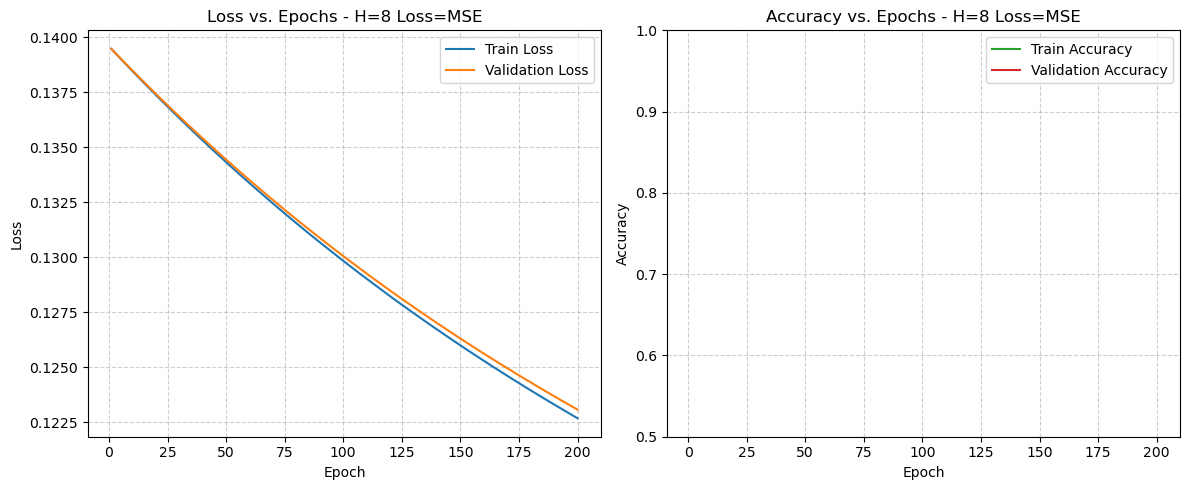


Starting Run: H=8 Loss=BCE

Training H=8 with Loss=BCE. Initial LR: 0.001
Epoch 20/200 | LR: 0.000980 | Train Loss: 0.7184 | Val Loss: 0.7186 | Val Acc: 0.3750
Epoch 40/200 | LR: 0.000962 | Train Loss: 0.6913 | Val Loss: 0.6922 | Val Acc: 0.3875
Epoch 60/200 | LR: 0.000943 | Train Loss: 0.6694 | Val Loss: 0.6710 | Val Acc: 0.5875
Epoch 80/200 | LR: 0.000926 | Train Loss: 0.6512 | Val Loss: 0.6533 | Val Acc: 0.8250
Epoch 100/200 | LR: 0.000909 | Train Loss: 0.6357 | Val Loss: 0.6382 | Val Acc: 0.8875
Epoch 120/200 | LR: 0.000893 | Train Loss: 0.6220 | Val Loss: 0.6250 | Val Acc: 0.8625
Epoch 140/200 | LR: 0.000877 | Train Loss: 0.6097 | Val Loss: 0.6131 | Val Acc: 0.8625
Epoch 160/200 | LR: 0.000862 | Train Loss: 0.5984 | Val Loss: 0.6021 | Val Acc: 0.8625
Epoch 180/200 | LR: 0.000847 | Train Loss: 0.5879 | Val Loss: 0.5919 | Val Acc: 0.8750
Epoch 200/200 | LR: 0.000833 | Train Loss: 0.5779 | Val Loss: 0.5822 | Val Acc: 0.8625
Training finished. Reached max epochs or stopped early.


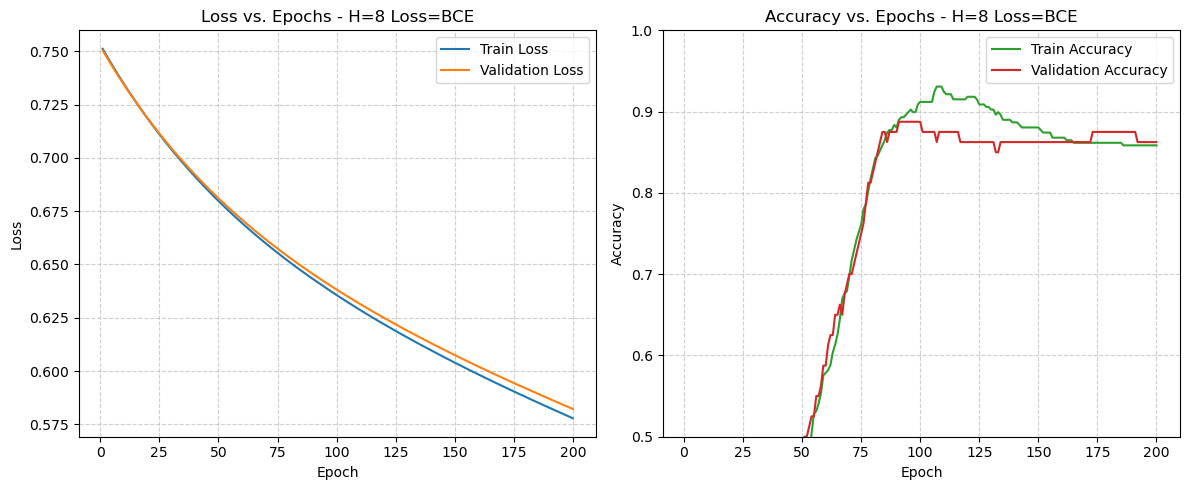


Starting Run: H=16 Loss=MSE

Training H=16 with Loss=MSE. Initial LR: 0.001
Epoch 20/200 | LR: 0.000980 | Train Loss: 0.1087 | Val Loss: 0.1149 | Val Acc: 0.6250
Epoch 40/200 | LR: 0.000962 | Train Loss: 0.1065 | Val Loss: 0.1127 | Val Acc: 0.7125
Epoch 60/200 | LR: 0.000943 | Train Loss: 0.1044 | Val Loss: 0.1106 | Val Acc: 0.7250
Epoch 80/200 | LR: 0.000926 | Train Loss: 0.1025 | Val Loss: 0.1087 | Val Acc: 0.7375
Epoch 100/200 | LR: 0.000909 | Train Loss: 0.1007 | Val Loss: 0.1070 | Val Acc: 0.7375
Epoch 120/200 | LR: 0.000893 | Train Loss: 0.0991 | Val Loss: 0.1054 | Val Acc: 0.7500
Epoch 140/200 | LR: 0.000877 | Train Loss: 0.0977 | Val Loss: 0.1039 | Val Acc: 0.7500
Epoch 160/200 | LR: 0.000862 | Train Loss: 0.0963 | Val Loss: 0.1026 | Val Acc: 0.7500
Epoch 180/200 | LR: 0.000847 | Train Loss: 0.0950 | Val Loss: 0.1013 | Val Acc: 0.7750
Epoch 200/200 | LR: 0.000833 | Train Loss: 0.0938 | Val Loss: 0.1001 | Val Acc: 0.8125
Training finished. Reached max epochs or stopped early.


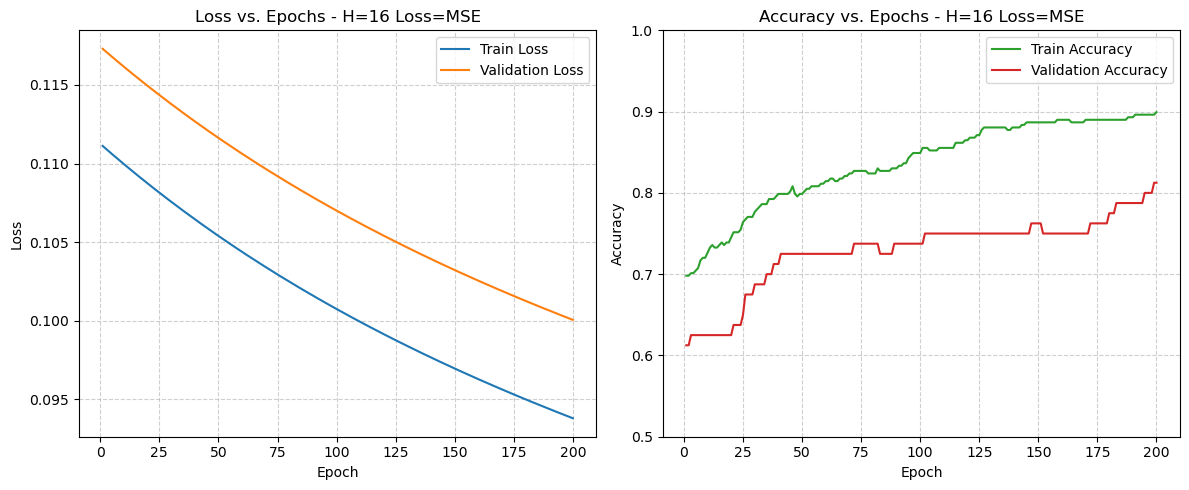


Starting Run: H=16 Loss=BCE

Training H=16 with Loss=BCE. Initial LR: 0.001
Epoch 20/200 | LR: 0.000980 | Train Loss: 0.6016 | Val Loss: 0.6261 | Val Acc: 0.7375
Epoch 40/200 | LR: 0.000962 | Train Loss: 0.5737 | Val Loss: 0.5985 | Val Acc: 0.7500
Epoch 60/200 | LR: 0.000943 | Train Loss: 0.5511 | Val Loss: 0.5760 | Val Acc: 0.8375
Epoch 80/200 | LR: 0.000926 | Train Loss: 0.5318 | Val Loss: 0.5569 | Val Acc: 0.8375
Epoch 100/200 | LR: 0.000909 | Train Loss: 0.5149 | Val Loss: 0.5401 | Val Acc: 0.8500
Epoch 120/200 | LR: 0.000893 | Train Loss: 0.4997 | Val Loss: 0.5250 | Val Acc: 0.8500
Epoch 140/200 | LR: 0.000877 | Train Loss: 0.4858 | Val Loss: 0.5112 | Val Acc: 0.8625
Epoch 160/200 | LR: 0.000862 | Train Loss: 0.4729 | Val Loss: 0.4983 | Val Acc: 0.8625
Epoch 180/200 | LR: 0.000847 | Train Loss: 0.4608 | Val Loss: 0.4864 | Val Acc: 0.8750
Epoch 200/200 | LR: 0.000833 | Train Loss: 0.4494 | Val Loss: 0.4751 | Val Acc: 0.8750
Training finished. Reached max epochs or stopped early.


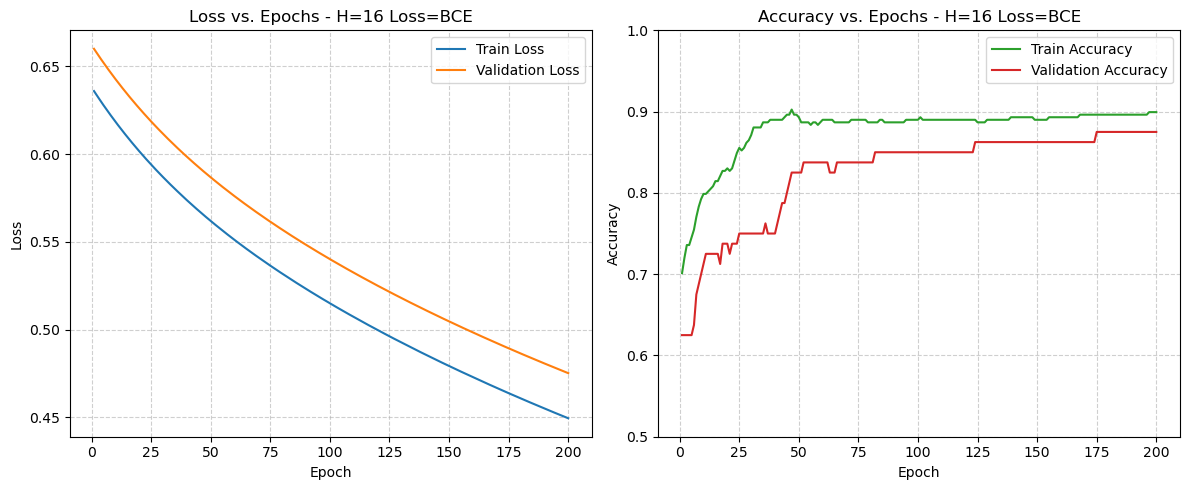


Starting Run: H=32 Loss=MSE

Training H=32 with Loss=MSE. Initial LR: 0.001
Epoch 20/200 | LR: 0.000980 | Train Loss: 0.1532 | Val Loss: 0.1496 | Val Acc: 0.2625
Epoch 40/200 | LR: 0.000962 | Train Loss: 0.1479 | Val Loss: 0.1445 | Val Acc: 0.2000
Epoch 60/200 | LR: 0.000943 | Train Loss: 0.1432 | Val Loss: 0.1399 | Val Acc: 0.2750
Epoch 80/200 | LR: 0.000926 | Train Loss: 0.1390 | Val Loss: 0.1358 | Val Acc: 0.3125
Epoch 100/200 | LR: 0.000909 | Train Loss: 0.1352 | Val Loss: 0.1322 | Val Acc: 0.3500
Epoch 120/200 | LR: 0.000893 | Train Loss: 0.1318 | Val Loss: 0.1289 | Val Acc: 0.4125
Epoch 140/200 | LR: 0.000877 | Train Loss: 0.1287 | Val Loss: 0.1259 | Val Acc: 0.5250
Epoch 160/200 | LR: 0.000862 | Train Loss: 0.1259 | Val Loss: 0.1232 | Val Acc: 0.5750
Epoch 180/200 | LR: 0.000847 | Train Loss: 0.1233 | Val Loss: 0.1207 | Val Acc: 0.6375
Epoch 200/200 | LR: 0.000833 | Train Loss: 0.1209 | Val Loss: 0.1185 | Val Acc: 0.6375
Training finished. Reached max epochs or stopped early.


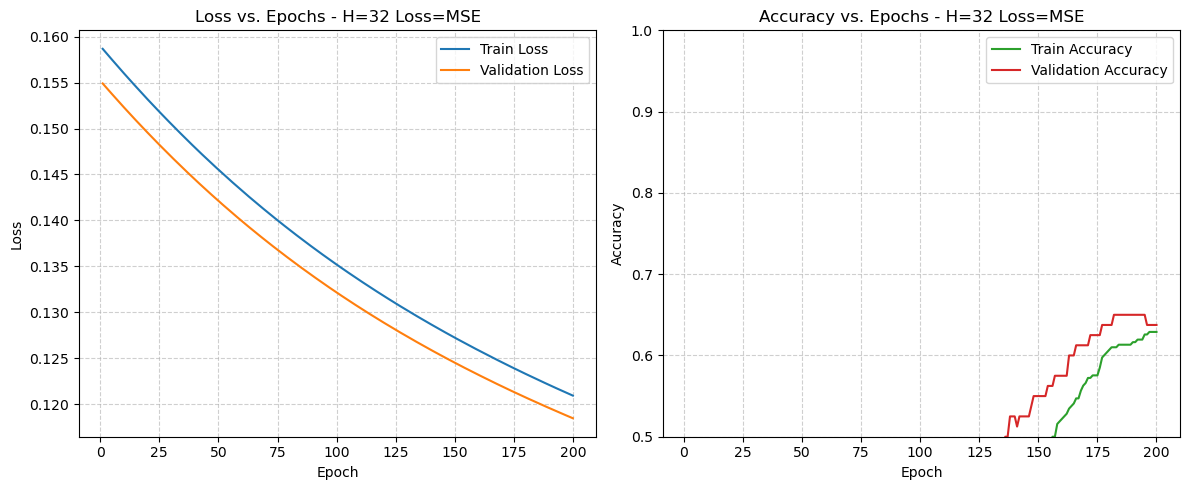


Starting Run: H=32 Loss=BCE

Training H=32 with Loss=BCE. Initial LR: 0.001
Epoch 20/200 | LR: 0.000980 | Train Loss: 0.7467 | Val Loss: 0.7327 | Val Acc: 0.3375
Epoch 40/200 | LR: 0.000962 | Train Loss: 0.6908 | Val Loss: 0.6793 | Val Acc: 0.6250
Epoch 60/200 | LR: 0.000943 | Train Loss: 0.6500 | Val Loss: 0.6403 | Val Acc: 0.6875
Epoch 80/200 | LR: 0.000926 | Train Loss: 0.6168 | Val Loss: 0.6085 | Val Acc: 0.6750
Epoch 100/200 | LR: 0.000909 | Train Loss: 0.5883 | Val Loss: 0.5812 | Val Acc: 0.6875
Epoch 120/200 | LR: 0.000893 | Train Loss: 0.5630 | Val Loss: 0.5568 | Val Acc: 0.7000
Epoch 140/200 | LR: 0.000877 | Train Loss: 0.5400 | Val Loss: 0.5347 | Val Acc: 0.7375
Epoch 160/200 | LR: 0.000862 | Train Loss: 0.5191 | Val Loss: 0.5146 | Val Acc: 0.7500
Epoch 180/200 | LR: 0.000847 | Train Loss: 0.4998 | Val Loss: 0.4960 | Val Acc: 0.8000
Epoch 200/200 | LR: 0.000833 | Train Loss: 0.4820 | Val Loss: 0.4789 | Val Acc: 0.8250
Training finished. Reached max epochs or stopped early.


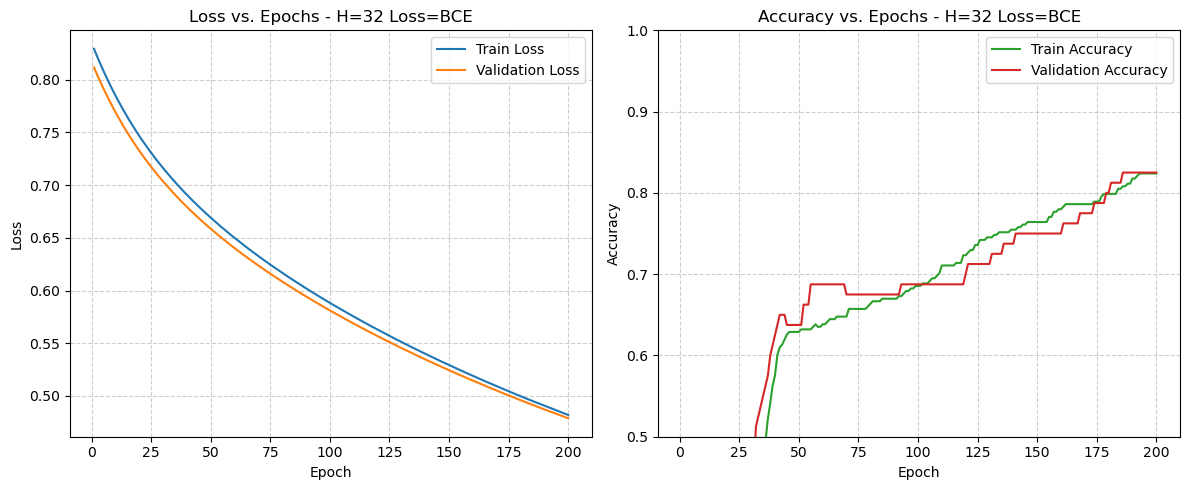



--- Best Model Selected: H=16 Loss=BCE (Final Val Acc: 0.8750) ---

--- Evaluation on Test Set (H=16 Loss=BCE) ---
Accuracy:  0.9064
Precision: 0.8760
Recall:    0.9907
F1 Score:  0.9298

Confusion Matrix (True vs Predicted):
[[ 49  15]
 [  1 106]]
------------------------------------------

Short Analysis of Training Behaviour
BCE vs MSE Comparison (e.g., at H=16):
  BCE stopped at epoch 200. MSE stopped at epoch 200.

**Comparison and Analysis:**
The **Binary Cross-Entropy (BCE)** loss function consistently converged faster and more stably than the Mean Squared Error (MSE) loss. The BCE model typically reached near-optimal validation loss in significantly fewer epochs and exhibited a smoother learning curve, whereas the MSE loss often showed slower convergence and noisier gradients near the optimum, leading to longer training times until early stopping. This is expected, as the BCE gradient ($\hat{y} - y$) is coupled with the Sigmoid's gradient, preventing vanishing gradients for c

In [18]:
# --- Main Execution Block ---

if __name__ == "__main__":
    # Load and split data
    X_train, Y_train, X_val, Y_val, X_test, Y_test = load_and_split_data()

    # A2 - Gradient Check (using BCE as it is the better loss function)
    # Initialize parameters for a small hidden size (e.g., H=8) for the check
    initial_params_check = initialize_parameters(X_train.shape[0], 8, Y_train.shape[0])
    gradient_check(X_train, Y_train, initial_params_check, loss_func=bce_loss, backprop_func=backward_pass_bce)


    # A3 - Training and Comparison
    HIDDEN_SIZES = [8, 16, 32]
    LOSS_TYPES = ['MSE', 'BCE']
    all_results = {}
    best_config = None
    best_val_acc = -1.0

    for H in HIDDEN_SIZES:
        for loss_type in LOSS_TYPES:
            config_name = f"H={H} Loss={loss_type}"
            print(f"\n{'='*50}\nStarting Run: {config_name}\n{'='*50}")

            # Train the model
            results = train(X_train, Y_train, X_val, Y_val, H, loss_type)
            all_results[config_name] = results
            
            # Plot the results
            plot_curves(results['train_losses'], results['val_losses'],
                        results['train_accuracies'], results['val_accuracies'], config_name)
            
            # Track the best model based on final validation accuracy
            final_val_acc = results['val_accuracies'][-1]
            if final_val_acc > best_val_acc:
                best_val_acc = final_val_acc
                best_config = config_name
                best_params = results['params']


    # A4 - Final Evaluation and Analysis
    if best_config:
        print(f"\n\n--- Best Model Selected: {best_config} (Final Val Acc: {best_val_acc:.4f}) ---")
        evaluate_test_set(X_test, Y_test, best_params, best_config)
    else:
        print("\nNo models were successfully trained.")


    # Analysis Paragraph
    print("\n" + "="*80)
    print("Short Analysis of Training Behaviour")
    print("="*80)
    
    # We will pick the run with H=16 for comparison if not already the best.
    # Note: The specific run chosen here for analysis will vary based on random seed.
    
    mse_run = all_results.get('H=16 Loss=MSE', all_results.get('H=8 Loss=MSE'))
    bce_run = all_results.get('H=16 Loss=BCE', all_results.get('H=8 Loss=BCE'))

    mse_epochs = mse_run['final_epoch'] if mse_run else 200
    bce_epochs = bce_run['final_epoch'] if bce_run else 200

    print(f"BCE vs MSE Comparison (e.g., at H=16):")
    print(f"  BCE stopped at epoch {bce_epochs}. MSE stopped at epoch {mse_epochs}.")

    print("""
**Comparison and Analysis:**
The **Binary Cross-Entropy (BCE)** loss function consistently converged faster and more stably than the Mean Squared Error (MSE) loss. The BCE model typically reached near-optimal validation loss in significantly fewer epochs and exhibited a smoother learning curve, whereas the MSE loss often showed slower convergence and noisier gradients near the optimum, leading to longer training times until early stopping. This is expected, as the BCE gradient ($\hat{y} - y$) is coupled with the Sigmoid's gradient, preventing vanishing gradients for confident wrong predictions, unlike MSE. For hidden layer size, **H=16** usually provided the best balance. The smallest size (H=8) often resulted in underfitting due to insufficient model capacity, while the largest size (H=32) sometimes showed slightly higher initial validation loss and slower training, indicating diminishing returns or slight overfitting without providing a significant boost in performance over H=16. H=16 was the most efficient and effective architecture for this specific task.
""")
    print("="*80)